In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
import statsmodels.api as sm

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# =========================
# STEP 1: SIMULATE A TINY MARKET
# =========================

T = 120   # number of days
N = 5     # number of stocks

dates = pd.date_range("2024-01-01", periods=T, freq="D")

# one hidden common factor
factor_true = np.random.normal(0, 0.01, T)

# each stock has its own loading on the common factor
betas_true = np.array([1.2, 1.0, 0.8, 1.1, 0.9])

# idiosyncratic noise
noise = np.random.normal(0, 0.005, size=(T, N))

# returns = factor part + idiosyncratic part
returns = factor_true.reshape(-1, 1) * betas_true.reshape(1, -1) + noise

returns_df = pd.DataFrame(
    returns,
    index=dates,
    columns=[f"Stock_{i+1}" for i in range(N)]
)

print("Returns shape:", returns_df.shape)
print(returns_df.head())

Returns shape: (120, 5)
             Stock_1   Stock_2   Stock_3   Stock_4   Stock_5
2024-01-01  0.009916  0.000420  0.010988 -0.001545  0.007405
2024-01-02  0.009293 -0.006335 -0.003938 -0.001023 -0.003762
2024-01-03  0.000019  0.006820 -0.000130  0.009493  0.001232
2024-01-04  0.026026  0.011314  0.010574  0.020821  0.007553
2024-01-05 -0.001673  0.004194 -0.009911 -0.001653 -0.000808


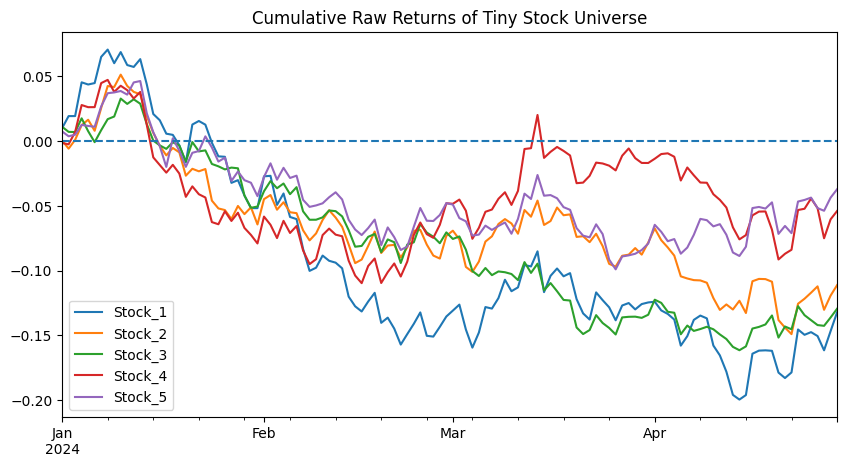

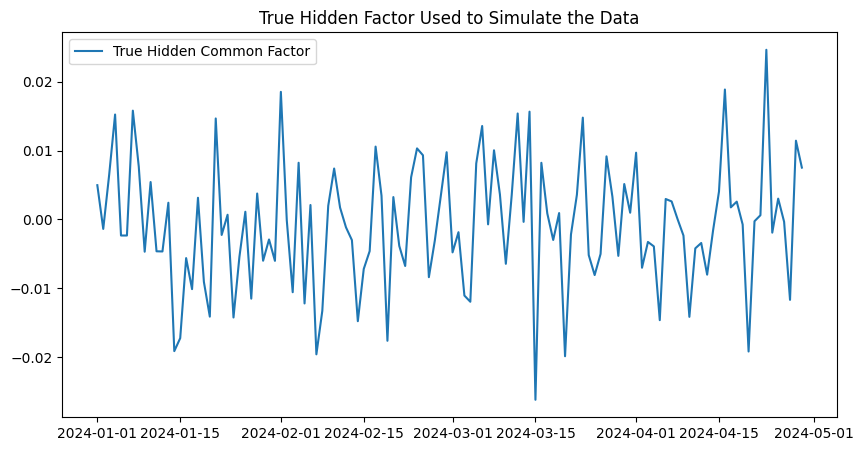

In [3]:
# =========================
# STEP 2: VISUALIZE RAW RETURNS
# =========================

returns_df.cumsum().plot(title="Cumulative Raw Returns of Tiny Stock Universe")
plt.axhline(0, linestyle="--")
plt.show()

plt.plot(dates, factor_true, label="True Hidden Common Factor")
plt.title("True Hidden Factor Used to Simulate the Data")
plt.legend()
plt.show()

In [4]:
# =========================
# STEP 3: STANDARDIZE RETURNS
# =========================

Y = (returns_df - returns_df.mean()) / returns_df.std()

print("Standardized return matrix shape:", Y.shape)
print(Y.head())
print("\nColumn means (should be near 0):")
print(Y.mean().round(4))
print("\nColumn stds (should be near 1):")
print(Y.std().round(4))

Standardized return matrix shape: (120, 5)
             Stock_1   Stock_2   Stock_3   Stock_4   Stock_5
2024-01-01  0.888468  0.131897  1.437284 -0.093181  0.758988
2024-01-02  0.838256 -0.529802 -0.340630 -0.048716 -0.339567
2024-01-03  0.090327  0.758722  0.112934  0.845695  0.151725
2024-01-04  2.187708  1.198939  1.387997  1.809275  0.773571
2024-01-05 -0.046086  0.501555 -1.052143 -0.102292 -0.048974

Column means (should be near 0):
Stock_1    0.0
Stock_2    0.0
Stock_3    0.0
Stock_4   -0.0
Stock_5    0.0
dtype: float64

Column stds (should be near 1):
Stock_1    1.0
Stock_2    1.0
Stock_3    1.0
Stock_4    1.0
Stock_5    1.0
dtype: float64


In [5]:
# =========================
# STEP 4: PCA TO EXTRACT COMMON FACTOR
# =========================

pca = PCA(n_components=1)
factor_pca = pca.fit_transform(Y).flatten()

loadings = pd.Series(
    pca.components_[0],
    index=Y.columns,
    name="PC1 Loading"
)

print("Explained variance ratio of PC1:", round(pca.explained_variance_ratio_[0], 4))
print("\nPC1 loadings:")
print(loadings.round(4))

Explained variance ratio of PC1: 0.8137

PC1 loadings:
Stock_1    0.4569
Stock_2    0.4426
Stock_3    0.4373
Stock_4    0.4528
Stock_5    0.4462
Name: PC1 Loading, dtype: float64


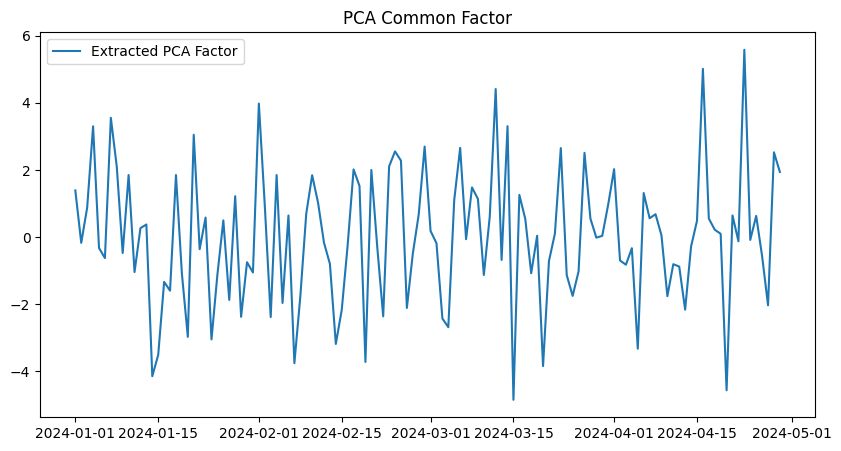

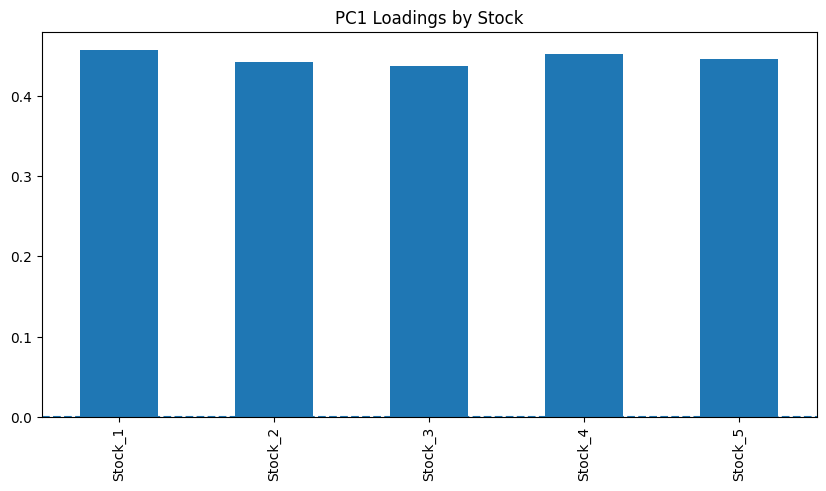

In [6]:
# =========================
# STEP 5: VISUALIZE PCA OUTPUT
# =========================

plt.plot(dates, factor_pca, label="Extracted PCA Factor")
plt.title("PCA Common Factor")
plt.legend()
plt.show()

loadings.plot(kind="bar", title="PC1 Loadings by Stock")
plt.axhline(0, linestyle="--")
plt.show()

In [7]:
# =========================
# STEP 6: REGRESS ONE STOCK ON THE FACTOR
# =========================

target_stock = "Stock_1"

X_reg = sm.add_constant(factor_pca)
model = sm.OLS(Y[target_stock], X_reg).fit()

alpha_hat = model.params[0]
beta_hat = model.params[1]

print(model.summary())
print("\nalpha_hat =", round(alpha_hat, 4))
print("beta_hat  =", round(beta_hat, 4))

                            OLS Regression Results                            
Dep. Variable:                Stock_1   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     665.4
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           2.48e-50
Time:                        08:16:43   Log-Likelihood:                -56.190
No. Observations:                 120   AIC:                             116.4
Df Residuals:                     118   BIC:                             122.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.006e-16      0.036   2.83e-15      1.0

C:\Users\Nish\AppData\Local\Temp\ipykernel_26412\2768251865.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  alpha_hat = model.params[0]
C:\Users\Nish\AppData\Local\Temp\ipykernel_26412\2768251865.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_hat = model.params[1]


In [8]:
# =========================
# STEP 7: COMPUTE RESIDUALS
# =========================

predicted = model.predict(X_reg)
residual = Y[target_stock] - predicted
residual.name = "Residual"

print(residual.head(10))
print("\nResidual mean:", round(residual.mean(), 6))
print("Residual std :", round(residual.std(), 6))

2024-01-01    0.253661
2024-01-02    0.917755
2024-01-03   -0.310434
2024-01-04    0.679131
2024-01-05    0.103497
2024-01-06    0.464767
2024-01-07    0.093773
2024-01-08   -0.415584
2024-01-09   -0.540561
2024-01-10   -0.064478
Freq: D, Name: Residual, dtype: float64

Residual mean: 0.0
Residual std : 0.388097


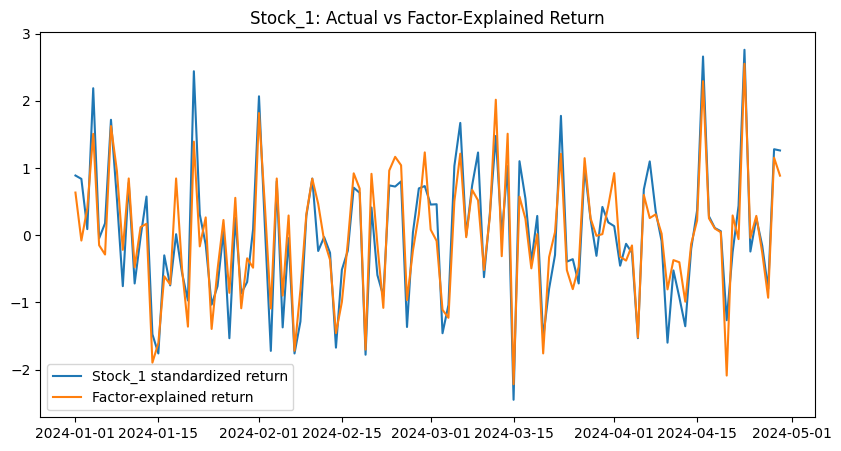

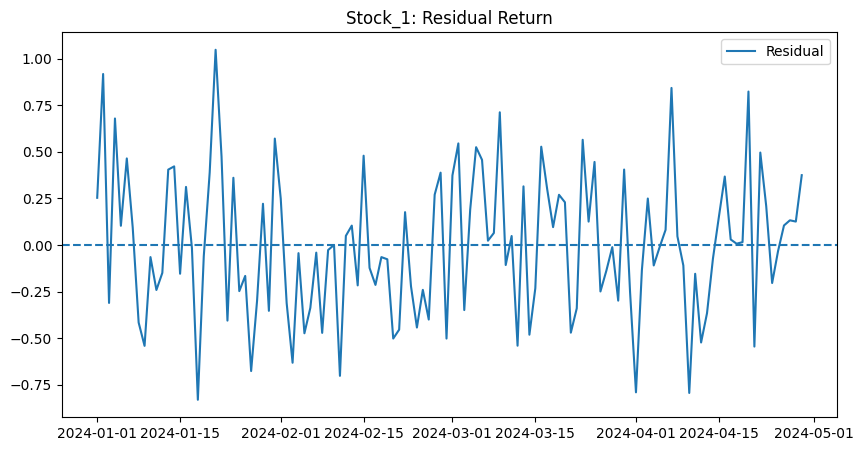

In [9]:
# =========================
# STEP 8: VISUALIZE ACTUAL VS FACTOR-EXPLAINED RETURN
# =========================

plt.plot(dates, Y[target_stock], label=f"{target_stock} standardized return")
plt.plot(dates, predicted, label="Factor-explained return")
plt.title(f"{target_stock}: Actual vs Factor-Explained Return")
plt.legend()
plt.show()

plt.plot(dates, residual, label="Residual")
plt.axhline(0, linestyle="--")
plt.title(f"{target_stock}: Residual Return")
plt.legend()
plt.show()

In [10]:
# =========================
# STEP 9: BUILD THE SPREAD LEVEL X_t
# X_t = X_{t-1} + epsilon_t
# =========================

spread = residual.cumsum()
spread.name = "x_t"

print(spread.head(10))

2024-01-01    0.253661
2024-01-02    1.171416
2024-01-03    0.860983
2024-01-04    1.540113
2024-01-05    1.643611
2024-01-06    2.108378
2024-01-07    2.202151
2024-01-08    1.786567
2024-01-09    1.246006
2024-01-10    1.181528
Freq: D, Name: x_t, dtype: float64


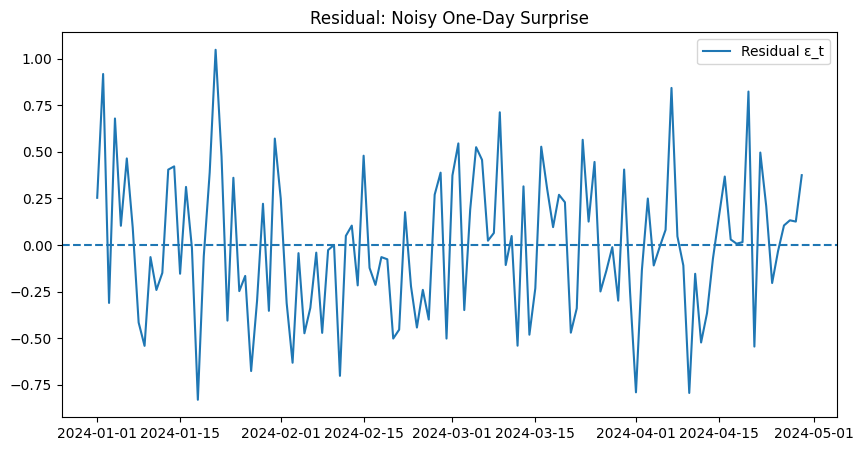

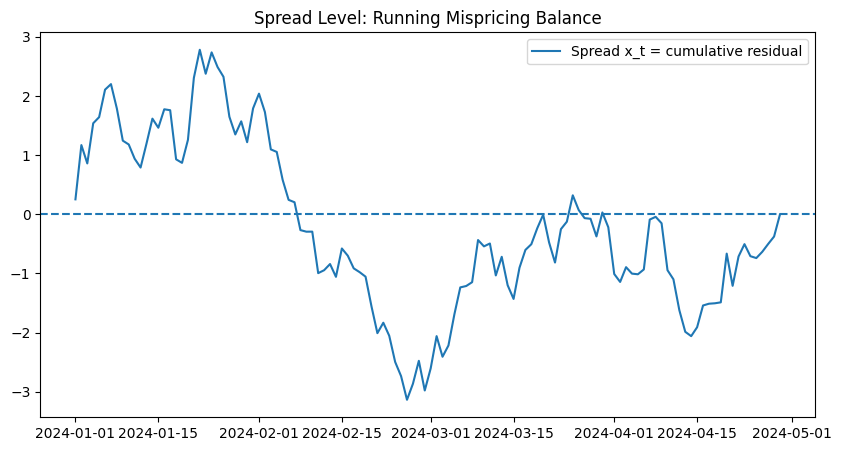

In [11]:
# =========================
# STEP 10: VISUALIZE WHY WE ACCUMULATE RESIDUALS
# =========================

plt.plot(dates, residual, label="Residual ε_t")
plt.axhline(0, linestyle="--")
plt.title("Residual: Noisy One-Day Surprise")
plt.legend()
plt.show()

plt.plot(dates, spread, label="Spread x_t = cumulative residual")
plt.axhline(0, linestyle="--")
plt.title("Spread Level: Running Mispricing Balance")
plt.legend()
plt.show()

In [12]:
# =========================
# STEP 11: KALMAN FILTER FOR FAIR VALUE m_t
# =========================

delta = 0.98   # state discount factor
m_list = []
P_list = []
K_list = []

m_prev = 0.0
P_prev = 1.0

obs_var = residual.var() * 5  # fixed observation variance for toy example

for x_t in spread.values:
    # predict
    R_t = P_prev / delta
    Q_t = R_t + obs_var

    # update
    K_t = R_t / Q_t
    m_t = m_prev + K_t * (x_t - m_prev)
    P_t = (1 - K_t) * R_t

    m_list.append(m_t)
    P_list.append(P_t)
    K_list.append(K_t)

    m_prev = m_t
    P_prev = P_t

kalman_mean = pd.Series(m_list, index=dates, name="m_t")
kalman_gain = pd.Series(K_list, index=dates, name="K_t")

print("Observation variance used:", round(obs_var, 6))
print(kalman_mean.head())

Observation variance used: 0.753095
2024-01-01    0.145947
2024-01-02    0.525291
2024-01-03    0.617281
2024-01-04    0.818939
2024-01-05    0.969298
Freq: D, Name: m_t, dtype: float64


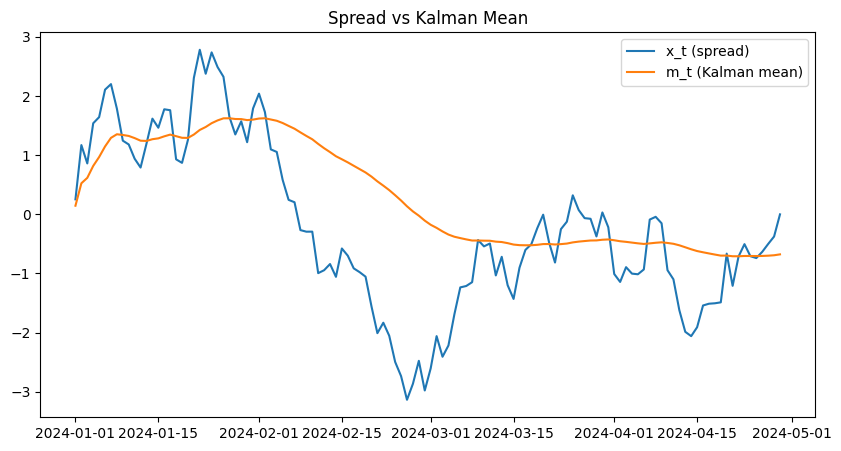

In [13]:
# =========================
# STEP 12: SPREAD VS KALMAN FAIR VALUE
# =========================

plt.plot(dates, spread, label="x_t (spread)")
plt.plot(dates, kalman_mean, label="m_t (Kalman mean)")
plt.title("Spread vs Kalman Mean")
plt.legend()
plt.show()

In [14]:
# =========================
# STEP 13: COMPUTE DEVIATION AND SIGNAL
# =========================

deviation = spread - kalman_mean
rolling_vol = deviation.rolling(20).std()

s_score = deviation / rolling_vol
s_score.name = "s_t"

out = pd.DataFrame({
    "x_t": spread,
    "m_t": kalman_mean,
    "deviation": deviation,
    "rolling_vol": rolling_vol,
    "s_t": s_score
})

print(out.head(25))

                 x_t       m_t  deviation  rolling_vol       s_t
2024-01-01  0.253661  0.145947   0.107714          NaN       NaN
2024-01-02  1.171416  0.525291   0.646125          NaN       NaN
2024-01-03  0.860983  0.617281   0.243701          NaN       NaN
2024-01-04  1.540113  0.818939   0.721174          NaN       NaN
2024-01-05  1.643611  0.969298   0.674313          NaN       NaN
2024-01-06  2.108378  1.147977   0.960401          NaN       NaN
2024-01-07  2.202151  1.293430   0.908720          NaN       NaN
2024-01-08  1.786567  1.354292   0.432275          NaN       NaN
2024-01-09  1.246006  1.342180  -0.096174          NaN       NaN
2024-01-10  1.181528  1.325723  -0.144195          NaN       NaN
2024-01-11  0.940597  1.289275  -0.348678          NaN       NaN
2024-01-12  0.791399  1.245429  -0.454030          NaN       NaN
2024-01-13  1.196183  1.241368  -0.045186          NaN       NaN
2024-01-14  1.618316  1.270622   0.347693          NaN       NaN
2024-01-15  1.464517  1.2

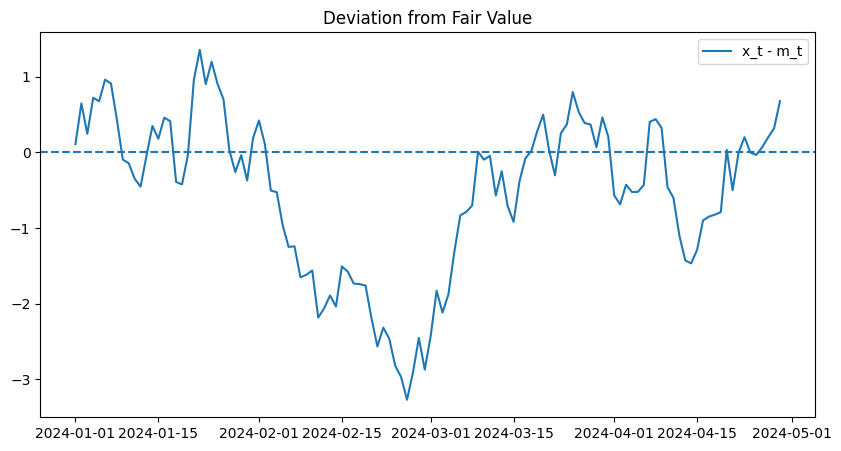

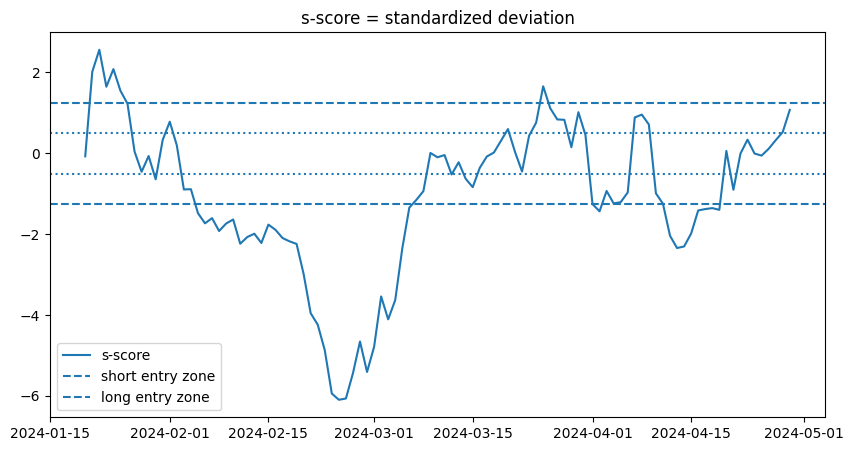

In [15]:
# =========================
# STEP 14: VISUALIZE THE SIGNAL
# =========================

plt.plot(dates, deviation, label="x_t - m_t")
plt.axhline(0, linestyle="--")
plt.title("Deviation from Fair Value")
plt.legend()
plt.show()

plt.plot(dates, s_score, label="s-score")
plt.axhline(1.25, linestyle="--", label="short entry zone")
plt.axhline(-1.25, linestyle="--", label="long entry zone")
plt.axhline(0.5, linestyle=":")
plt.axhline(-0.5, linestyle=":")
plt.title("s-score = standardized deviation")
plt.legend()
plt.show()

In [16]:
# =========================
# STEP 15: SIMPLE TOY TRADING RULE
# =========================

ENTRY = 1.25
EXIT = 0.50

position = []
pos = 0

for s in s_score.fillna(0):
    if pos == 0:
        if s > ENTRY:
            pos = -1   # short
        elif s < -ENTRY:
            pos = 1    # long
    elif pos == 1:
        if s > -EXIT:
            pos = 0
    elif pos == -1:
        if s < EXIT:
            pos = 0

    position.append(pos)

position = pd.Series(position, index=dates, name="position")

print(position.value_counts())

position
 0    63
 1    47
-1    10
Name: count, dtype: int64


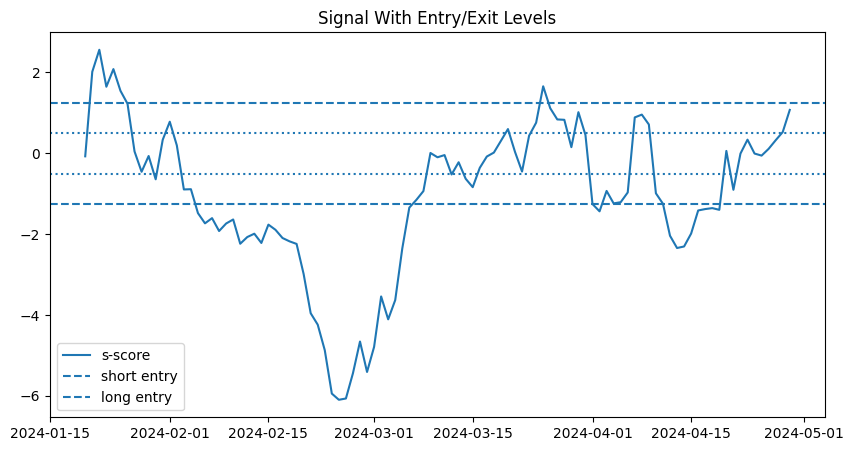

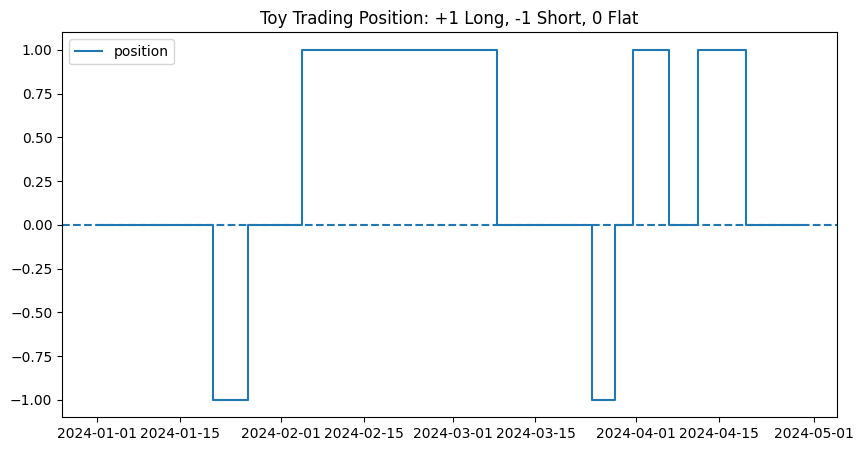

In [17]:
# =========================
# STEP 16: VISUALIZE POSITIONS ON TOP OF SIGNAL
# =========================

plt.plot(dates, s_score, label="s-score")
plt.axhline(1.25, linestyle="--", label="short entry")
plt.axhline(-1.25, linestyle="--", label="long entry")
plt.axhline(0.5, linestyle=":")
plt.axhline(-0.5, linestyle=":")
plt.title("Signal With Entry/Exit Levels")
plt.legend()
plt.show()

plt.step(dates, position, where="mid", label="position")
plt.axhline(0, linestyle="--")
plt.title("Toy Trading Position: +1 Long, -1 Short, 0 Flat")
plt.legend()
plt.show()

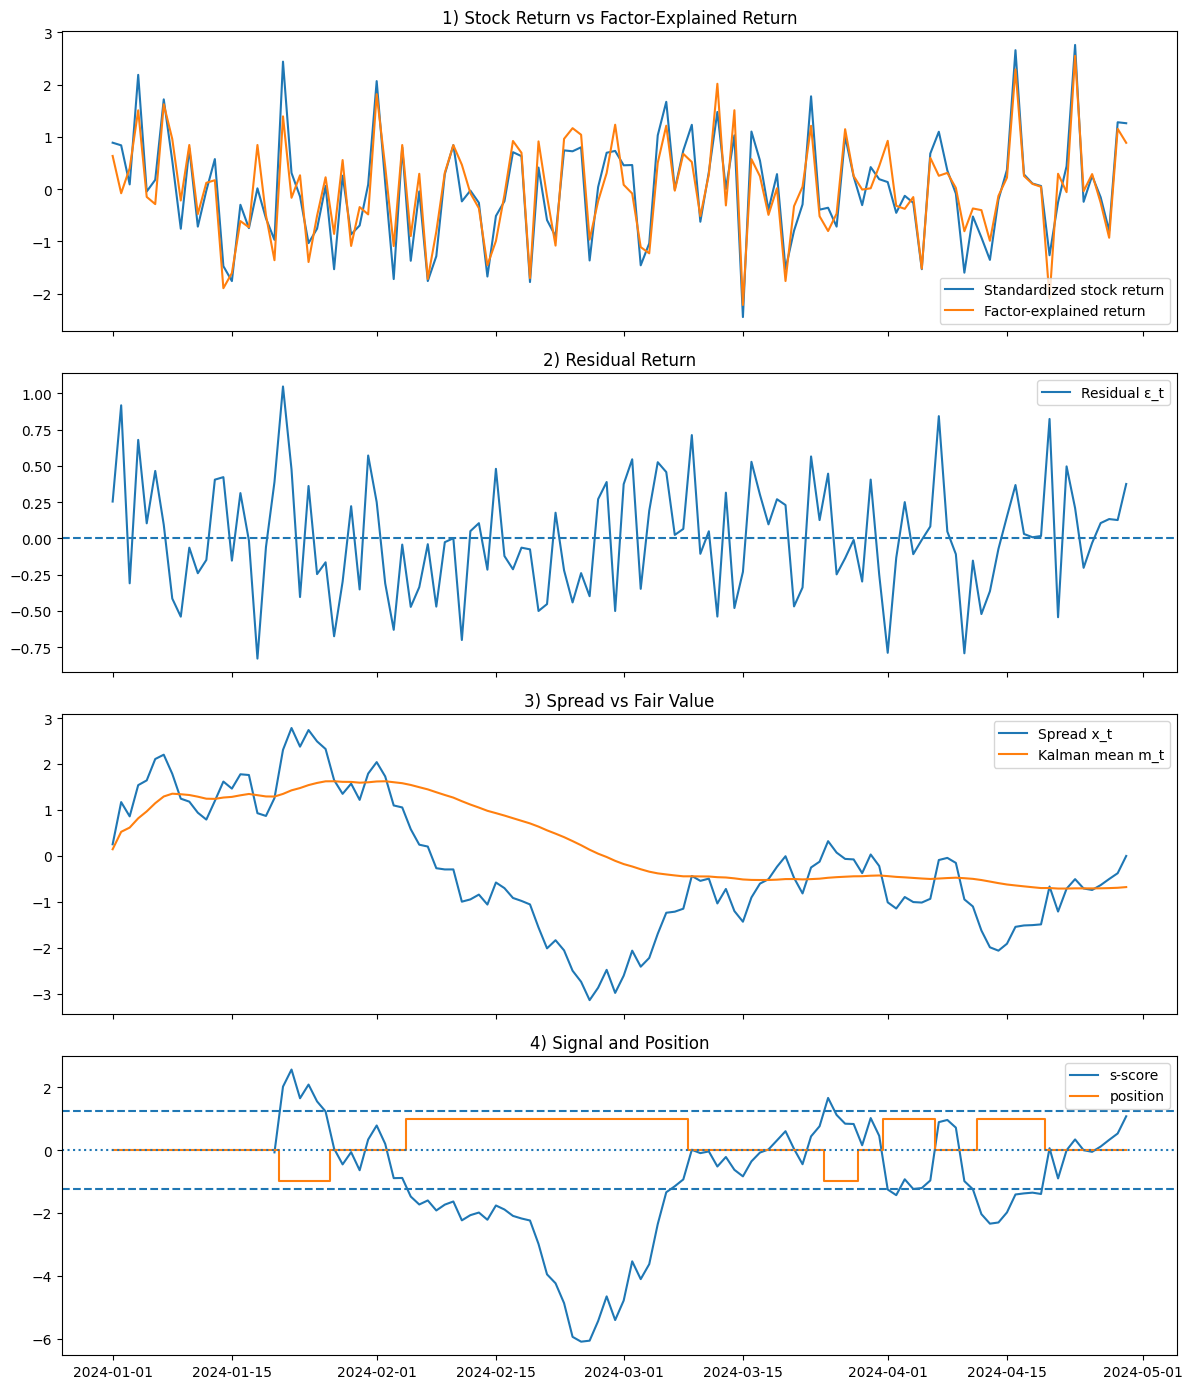

In [18]:
# =========================
# STEP 17: FINAL COMBINED VIEW
# =========================

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

axes[0].plot(dates, Y[target_stock], label="Standardized stock return")
axes[0].plot(dates, predicted, label="Factor-explained return")
axes[0].set_title("1) Stock Return vs Factor-Explained Return")
axes[0].legend()

axes[1].plot(dates, residual, label="Residual ε_t")
axes[1].axhline(0, linestyle="--")
axes[1].set_title("2) Residual Return")
axes[1].legend()

axes[2].plot(dates, spread, label="Spread x_t")
axes[2].plot(dates, kalman_mean, label="Kalman mean m_t")
axes[2].set_title("3) Spread vs Fair Value")
axes[2].legend()

axes[3].plot(dates, s_score, label="s-score")
axes[3].step(dates, position, where="mid", label="position")
axes[3].axhline(1.25, linestyle="--")
axes[3].axhline(-1.25, linestyle="--")
axes[3].axhline(0, linestyle=":")
axes[3].set_title("4) Signal and Position")
axes[3].legend()

plt.tight_layout()
plt.show()